In [390]:
import numpy as np 
np.random.seed(420)

import pandas as pd 

In [391]:
def simulation(N=1000,I0=5,repo=2,infectious_period=2,start=0,end=32):
    #--simulation
    gamma             = 1./infectious_period
    eps = np.finfo(float).eps

    S0, I0, R0, i0 = N-I0, I0, 0, I0
    y     = [ (S0,I0,R0,i0) ]

    dt        = 1./7
    times     = np.linspace(start,end,(end-start)*7)
    T         = len(times)
    
    for t in times:
        S,I,R,i = y[-1]
        beta = repo*gamma
        
        infection = np.random.poisson( dt*(beta*S*I/N)  )
        recover   = np.random.poisson( dt*(gamma*I) )

        S = np.clip(S - infection         ,0,N)
        I = np.clip(I + infection-recover ,0,N)
        R = np.clip(R + recover           ,0,N)
        i+=infection

        y.append((S,I,R,i))

    S,I,R,i = zip(*y)
    i       = np.diff(i)

    weeks = np.arange(0,32)
    i_weekly  = i.reshape(32,-1).sum(-1)
    
    return weeks,i_weekly, y


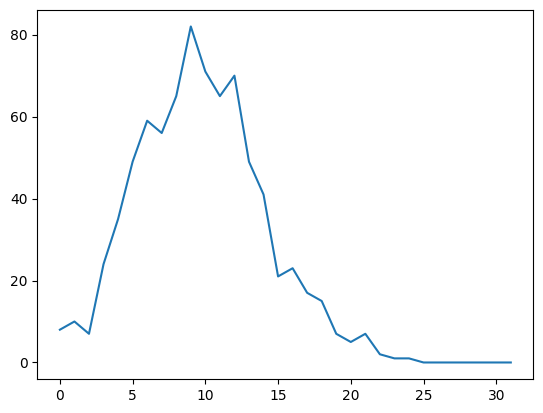

In [392]:
N = 1000
times,inc_cases,y = simulation(N=1000,I0=5,repo=2,infectious_period=2,start=0,end=32)
plt.plot(times,inc_cases)

In [393]:
def fit_a_simple_SIR(times,i,N):
    import numpy as np
    from scipy.integrate import odeint
    from scipy.optimize import minimize
    from scipy.stats import poisson
    import matplotlib.pyplot as plt
    
    # --- Simulate SIR model ---
    def sir(y, t, beta, gamma, N):
        S, I, R, C = y  # C: cumulative infections
        dS = -beta * S * I / N
        dI = beta * S * I / N - gamma * I
        dR = gamma * I
        dC = beta * S * I / N  # cumulative infections
        return [dS, dI, dR, dC]
    
    def simulate_sir(t, beta, gamma, S0, I0, R0, N):
        C0 = I0  # Assume initial cumulative cases equals I0
        y0 = [S0, I0, R0, C0]
        sol = odeint(sir, y0, np.array([min(t)-1] + list(t)), args=(beta, gamma, N))
        S, I, R, C = sol.T
        incident = np.diff(C)
        return incident, sol
        
    # Poisson negative log likelihood
    def neg_log_likelihood(params, t, data, N):
        beta, gamma = params
        S0, I0, R0 = N - 1, 1, 0  # assume 1 initial infection
        pred_incident, _ = simulate_sir(t, beta, gamma, S0, I0, R0, N)
        
        # Likelihood only on time points where we have observations
        eps = 1e-6  # to avoid log(0)
        log_probs = poisson.logpmf(data, pred_incident + eps)
        return -np.sum(log_probs)
    
    # Fit parameters
    def fit_sir(t, data, N):
        init_params = [0.5, 0.1]
        result = minimize(neg_log_likelihood, init_params, args=(t, data, N),
                          bounds=[(1e-4, 5.0), (1e-4, 5.0)])
        return result.x
    
    estimated_beta, estimated_gamma = fit_sir(times, i, N=N)
    
    forecast_times = np.arange(min(times)-1, max(times)+4)
    fitted_incident_SIR, sol = simulate_sir(forecast_times
                                              , estimated_beta,estimated_gamma
                                              , N - 1, 1, 0, N)
    return fitted_incident_SIR[-4:]

In [394]:
def fit_a_simple_SEIR(times,i,N):
    import numpy as np
    from scipy.integrate import odeint
    from scipy.optimize import minimize
    from scipy.stats import poisson
    import matplotlib.pyplot as plt
    
    def seir(y, t, beta, sigma, gamma, N):
        S, E, I, R, C = y  # C: cumulative infections
        dS = -beta * S * I / N
        dE = beta * S * I / N - sigma * E
        dI = sigma * E - gamma * I
        dR = gamma * I
        dC = sigma * E  # cumulative incidence = those entering infectious
        return [dS, dE, dI, dR, dC]
    
    def simulate_seir(t, beta, sigma, gamma, S0, E0, I0, R0, N):
        C0 = 0  # assume no cases yet recorded
        y0 = [S0, E0, I0, R0, C0]
        sol = odeint(seir, y0, np.array([min(t)-1] + list(t)), args=(beta, sigma, gamma, N))
        S, E, I, R, C = sol.T
        incident = np.diff(C)
        return incident, sol
    
    def neg_log_likelihood(params, t, data, N):
        beta, sigma, gamma = params
        S0, E0, I0, R0 = N - 2, 1, 1, 0  # small initial seed
        pred_incident, _ = simulate_seir(t, beta, sigma, gamma, S0, E0, I0, R0, N)
        
        eps = 1e-6
        log_probs = poisson.logpmf(data, pred_incident + eps)
        return -np.sum(log_probs)
        
    def fit_seir(t, data, N):
        init_params = [0.5, 0.5, 0.1]  # beta, sigma, gamma
        bounds = [(1e-4, 5.0), (1e-4, 5.0), (1e-4, 5.0)]
        result = minimize(neg_log_likelihood, init_params, args=(t, data, N),
                          bounds=bounds)
        return result.x
    
    estimated_beta, estimated_sigma, estimated_gamma = fit_seir(times, i, N=N)

    forecast_times = np.arange(min(times)-1, max(times)+4)


    
    fitted_incident_SEIR, sol = simulate_seir(forecast_times
                                              , estimated_beta, estimated_sigma, estimated_gamma
                                              , N - 2, 1, 1, 0, N)
    return fitted_incident_SEIR[-4:]

In [395]:
def fit_simple_kalman(times,i):
    import statsmodels.api as sm
    
    mod = sm.tsa.UnobservedComponents(i, level='local level')
    res = mod.fit()
    
    # Forecast 4 steps ahead
    forecast = res.get_forecast(steps=4)

    means = forecast.predicted_mean
    ses   = forecast.se_mean

    return means,ses

In [396]:
#--build forecasts over intervals  

interval_begin = np.array(list(np.arange(0,100+10,10)))
interval_end = np.array(list(np.arange(10,100+10,10)) + [N])

def compute_forecasts(times,i):
    import scipy
    
    #start with 4 data points 
    forecasts = {"model":[],"week":[],"forecast_ahead":[], "bin_start":[],"bin_end":[],"prob":[] }
    for t in times[4:]:
        cut_times = times[:t]
        cut_incs  = i[:t]

        #fit SIR, SEIR, and Kalman 
        forecast_poisson_params_SIR   = fit_a_simple_SIR(cut_times ,cut_incs,N)
        forecast_poisson_params_SEIR  = fit_a_simple_SEIR(cut_times,cut_incs,N)
        forecast_normal_params_kalman = fit_simple_kalman(cut_times,cut_incs) 

        #compute log score
        for forecast_time in [0,1,2,3]:
            if t+forecast_time >= 32:
                continue
            forecast_ahead = t+forecast_time #np.min( [t+forecast_time, 32] )

            for start,end in zip(interval_begin,interval_end):

                pmf = scipy.stats.poisson(forecast_poisson_params_SIR[forecast_time])
                prob = pmf.cdf( end ) - pmf.cdf( start-0.1 )

                #return forecast_poisson_params_SIR[forecast_time],pmf
                
                forecasts["model"].append( "SIR" )
                forecasts["week"].append( t )
                forecasts["forecast_ahead"].append( forecast_time )
                forecasts["bin_start"].append(start)
                forecasts["bin_end"].append(end)
                forecasts["prob"].append( prob )
    
                pmf = scipy.stats.poisson(forecast_poisson_params_SEIR[forecast_time])
                prob = pmf.cdf( end ) - pmf.cdf( start-0.1 )
                
                forecasts["model"].append( "SEIR" )
                forecasts["week"].append( t )
                forecasts["forecast_ahead"].append( forecast_time )
                forecasts["bin_start"].append(start)
                forecasts["bin_end"].append(end)
                forecasts["prob"].append( prob )
            
                means,ses = forecast_normal_params_kalman
                pmf = scipy.stats.poisson(means[forecast_time])
                prob = pmf.cdf( end ) - pmf.cdf( start-0.1 )
                
                forecasts["model"].append( "Kalman" )
                forecasts["week"].append( t )
                forecasts["forecast_ahead"].append( forecast_time )
                forecasts["bin_start"].append(start)
                forecasts["bin_end"].append(end)
                forecasts["prob"].append( prob )

    return pd.DataFrame(forecasts)
forecasts = compute_forecasts(times,inc_cases)

In [397]:
import scipy.stats


In [398]:
#def compute_model_logscores( forecasts, times, i):
observed = pd.DataFrame({"evaluation_week":times, "truth":inc_cases})

forecasts["evaluation_week"] = forecasts.week+forecasts.forecast_ahead+1
forecasts_plus_truth = forecasts.merge( observed, on = ["evaluation_week"] )
forecasts_plus_truth = forecasts_plus_truth.loc[ (forecasts_plus_truth.bin_start <= forecasts_plus_truth.truth) & (forecasts_plus_truth.truth < forecasts_plus_truth.bin_end) ]
forecasts_plus_truth["logscore"] = np.clip(np.log( forecasts_plus_truth.prob ),-10,0)
forecasts_plus_truth

/Users/tommcandrew/teaching/.teaching/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,model,week,forecast_ahead,bin_start,bin_end,prob,evaluation_week,truth,logscore
12,SIR,4,0,40,50,0.003624,5,49,-5.620176
13,SEIR,4,0,40,50,0.011851,5,49,-4.435329
14,Kalman,4,0,40,50,0.000007,5,49,-10.000000
48,SIR,4,1,50,60,0.000191,6,59,-8.564648
49,SEIR,4,1,50,60,0.007384,6,59,-4.908454
...,...,...,...,...,...,...,...,...,...
3301,SEIR,29,1,0,10,1.000000,31,0,0.000000
3302,Kalman,29,1,0,10,1.000000,31,0,0.000000
3333,SIR,30,0,0,10,1.000000,31,0,0.000000
3334,SEIR,30,0,0,10,1.000000,31,0,0.000000


In [399]:
scoreMatrix = pd.pivot_table(forecasts_plus_truth
                             , index=["evaluation_week"]
                             , columns = ["model"]
                             , values = ["logscore"])
scoreMatrix

logscore                            
model                  Kalman          SEIR           SIR
evaluation_week                                          
5               -1.000000e+01 -4.435329e+00 -5.620176e+00
6               -7.312557e+00 -3.126092e+00 -5.471958e+00
7               -5.173789e+00 -1.395455e+00 -3.561289e+00
8               -5.772904e+00 -1.928010e+00 -4.816668e+00
9               -7.943546e+00 -5.502819e+00 -1.000000e+01
10              -3.252107e+00 -6.154229e+00 -9.778371e+00
11              -1.305991e+00 -7.151150e+00 -8.436443e+00
12              -1.624255e+00 -9.486189e+00 -1.000000e+01
13              -5.340141e+00 -4.669192e+00 -6.281895e+00
14              -5.702421e+00 -6.506450e+00 -7.640653e+00
15              -9.005591e+00 -1.194661e+00 -1.839155e+00
16              -7.279195e+00 -2.169654e+00 -2.959602e+00
17              -7.298060e+00 -3.395119e-01 -4.940060e-01
18              -5.091426e+00 -9.935145e-01 -1.253799e+00
19              -6.078585e+00 -6.122603e-02 -4.211390e-02
20              -4.111871e+00 -7.611800e-03 -5.114944e-03
21              -2.869044e+00 -5.879647e-04 -3.928057e-04
22              -1.316013e+00 -2.846486e-05 -1.954955e-05
23              -5.885923e-01 -1.115986e-06 -7.936016e-07
24              -5.530871e-02 -3.107171e-08 -2.358031e-08
25              -2.937913e-02 -7.041214e-10 -5.781575e-10
26              -2.593166e-02 -1.397857e-11 -1.251532e-11
27              -2.082089e-06 -2.223777e-13 -2.204903e-13
28              -5.023883e-09 -3.275158e-15 -3.608225e-15
29              -2.511942e-09  0.000000e+00 -5.551115e-17
30               0.000000e+00  0.000000e+00  0.000000e+00
31               0.000000e+00  0.000000e+00  0.000000e+00

In [400]:
component_models = [y for (x,y) in scoreMatrix.columns]

corr_matrix = scoreMatrix.corr(method="pearson")
corr_matrix = corr_matrix.replace(np.nan,0)

#--remove diagonals (correlatin of 1)
np.fill_diagonal(corr_matrix.values,0)

corr_matrix

logscore                    
model              Kalman      SEIR       SIR
         model                               
logscore Kalman  0.000000  0.302393  0.399278
         SEIR    0.302393  0.000000  0.960974
         SIR     0.399278  0.960974  0.000000

In [401]:
##Cluster
thresh      = 0.80
thresh      = float(thresh)

#--removing multi index with label "logscore" so that the columns and rows are labeled by model
corr_matrix.index   = [y for x,y in corr_matrix.index]
corr_matrix.columns = [y for x,y in corr_matrix.columns] 

#--pick random model
models = corr_matrix.index

random_model_to_start = np.random.choice(models)
models = models[models!=random_model_to_start]

clusters = [ [random_model_to_start] ]

while len(models) >0:
    random_model = np.random.choice(models)

    #--decide if this model can belong to any of the current clusters.
    cluster_assigned=0
    for cluster_number, cluster in enumerate(clusters):
        if np.all( np.abs(corr_matrix.loc[random_model, cluster]) >thresh):
            clusters[cluster_number].append(random_model)
            cluster_assigned=1
            
    #--if not then generate a new cluster
    if cluster_assigned==0:
        clusters.append( [random_model] )
    models = models[ models != random_model]

#--build dataframe of clusters
component_model_2_cluster = { "model":[], "cluster":[] }
for cluster_num,cluster in enumerate(clusters):
    for node in cluster:
        component_model_2_cluster["cluster"].append(cluster_num)
        component_model_2_cluster["model"].append( node )
component_model_2_cluster = pd.DataFrame(component_model_2_cluster)

component_model_2_cluster

,model,cluster
0,Kalman,0
1,SEIR,1
2,SIR,1


In [402]:
#--append cluster membership to forecasts 
forecasts_and_clusters = forecasts.merge( component_model_2_cluster, on = ["model"])
forecasts_and_clusters.head()

,model,week,forecast_ahead,bin_start,bin_end,prob,evaluation_week,cluster
0,SIR,4,0,0,10,0.000558,5,1
1,SEIR,4,0,0,10,0.000156,5,1
2,Kalman,4,0,0,10,0.026653,5,0
3,SIR,4,0,10,20,0.181167,5,1
4,SEIR,4,0,10,20,0.098627,5,1


In [403]:
##aggregate

score_matrix = scoreMatrix.apply( lambda x: pd.Series({"med_logscore": np.median(x)}), 0).melt( value_name = "med_logscore" )
score_matrix = score_matrix.merge( component_model_2_cluster, on = ["model"])

def find_best_logscore(x):
    best_score = x.med_logscore.max()
    return x.loc[ x.med_logscore == best_score, ["cluster","model"] ] #there may be more than one model per cluster that is "best"
top_models_per_cluster = score_matrix.groupby(["cluster"]).apply( find_best_logscore).reset_index(drop=True)

#--subset to top models only
top_forecasts = forecasts_and_clusters.merge( top_models_per_cluster, on = ["model","cluster"] )

print(top_forecasts)

cluster_forecasts = top_forecasts.groupby(["cluster","week","forecast_ahead","evaluation_week","bin_start","bin_end"]).apply( lambda x:  pd.Series({"prob":x.prob.mean()}),include_groups=False).reset_index()
cluster_forecasts

/var/folders/gz/t2mqv3h97_bcfv3l8vcgf5rc0000gp/T/ipykernel_33364/1202271696.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_models_per_cluster = score_matrix.groupby(["cluster"]).apply( find_best_logscore).reset_index(drop=True)


       None   model  med_logscore  cluster
0  logscore  Kalman     -3.252107        0
1  logscore    SEIR     -0.339512        1
2  logscore     SIR     -0.494006        1
       model  week  forecast_ahead  bin_start  bin_end      prob  \
0       SEIR     4               0          0       10  0.000156   
1     Kalman     4               0          0       10  0.026653   
2       SEIR     4               0         10       20  0.098627   
3     Kalman     4               0         10       20  0.696136   
4       SEIR     4               0         20       30  0.683305   
...      ...   ...             ...        ...      ...       ...   
2327  Kalman    31               0         80       90  0.000000   
2328    SEIR    31               0         90      100  0.000000   
2329  Kalman    31               0         90      100  0.000000   
2330    SEIR    31               0        100     1000  0.000000   
2331  Kalman    31               0        100     1000  0.000000   

      evalu

,cluster,week,forecast_ahead,evaluation_week,bin_start,bin_end,prob
0,0,4,0,5,0,10,0.026653
1,0,4,0,5,10,20,0.696136
2,0,4,0,5,20,30,0.368445
3,0,4,0,5,30,40,0.007180
4,0,4,0,5,40,50,0.000007
...,...,...,...,...,...,...,...
2327,1,31,0,32,60,70,0.000000
2328,1,31,0,32,70,80,0.000000
2329,1,31,0,32,80,90,0.000000
2330,1,31,0,32,90,100,0.000000


In [404]:
#--If you want to run an adaptive algorithm then you need to score the cluster forecasts

d = cluster_forecasts

observed = pd.DataFrame({"evaluation_week":times, "truth":inc_cases})

cluster_forecasts_plus_truth = cluster_forecasts.merge( observed, on = ["evaluation_week"] )
cluster_forecasts_plus_truth = cluster_forecasts_plus_truth.loc[ (cluster_forecasts_plus_truth.bin_start <= cluster_forecasts_plus_truth.truth) & (cluster_forecasts_plus_truth.truth < cluster_forecasts_plus_truth.bin_end) ]
cluster_forecasts_plus_truth["logscore"] = np.clip(np.log( cluster_forecasts_plus_truth.prob ),-10,0)
cluster_forecasts_plus_truth

,cluster,week,forecast_ahead,evaluation_week,bin_start,bin_end,prob,truth,logscore
4,0,4,0,5,40,50,7.404698e-06,49,-10.000000
16,0,4,1,6,50,60,7.141280e-10,59,-10.000000
27,0,4,2,7,50,60,7.141280e-10,56,-10.000000
39,0,4,3,8,60,70,9.880985e-15,65,-10.000000
49,0,5,0,6,50,60,9.802533e-03,59,-4.625114
...,...,...,...,...,...,...,...,...,...
2189,1,28,1,30,0,10,1.000000e+00,0,0.000000
2200,1,28,2,31,0,10,1.000000e+00,0,0.000000
2211,1,29,0,30,0,10,1.000000e+00,0,0.000000
2222,1,29,1,31,0,10,1.000000e+00,0,0.000000


In [405]:
#--Pooling Equal weights 

def equal_weight(x):
    return pd.Series({"prob":x.prob.mean()})
cap_ensemble = cluster_forecasts.groupby(["week","evaluation_week","bin_start","bin_end"]).apply(equal_weight,include_groups=False)
cap_ensemble = cap_ensemble.reset_index()

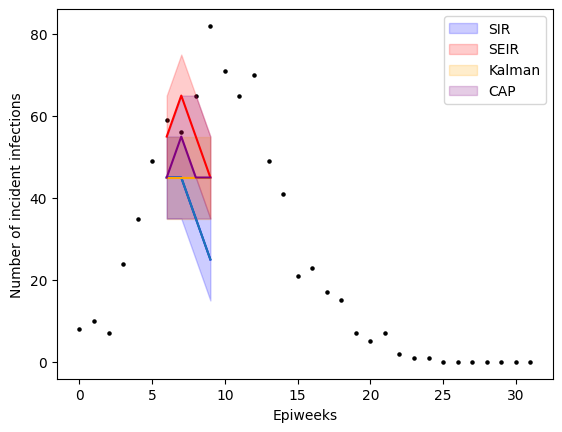

In [406]:
plt.scatter(times,inc_cases, s=5, color="k")

FORECAST_TIME = 6

SIR = forecasts.loc[ (forecasts.model=="SIR") & (forecasts.week==FORECAST_TIME) ]
def find_qs(x,q=0.50):
    idx = np.argmin(np.abs(np.cumsum(x.prob) - q))
    x = x.iloc[idx]
    return 0.5*(x.bin_start+x.bin_end)
    
medians = SIR.groupby(["evaluation_week"]).apply(find_qs              ,include_groups=False)
_10 = SIR.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.10),include_groups=False)
_90 = SIR.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.90),include_groups=False)

plt.plot(np.arange(FORECAST_TIME,FORECAST_TIME+4), medians, color="blue")
plt.fill_between(np.arange(FORECAST_TIME,FORECAST_TIME+4), _10,_90,alpha=0.20,color="blue",label="SIR")
plt.plot(np.arange(FORECAST_TIME,FORECAST_TIME+4), medians)


SEIR = forecasts.loc[ (forecasts.model=="SEIR") & (forecasts.week==6) ]
def find_qs(x,q=0.50):
    idx = np.argmin(np.abs(np.cumsum(x.prob) - q))
    x = x.iloc[idx]
    return 0.5*(x.bin_start+x.bin_end)
    
medians = SEIR.groupby(["evaluation_week"]).apply(find_qs              ,include_groups=False)
_10 = SEIR.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.10),include_groups=False)
_90 = SEIR.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.90),include_groups=False)

plt.plot(np.arange(FORECAST_TIME,FORECAST_TIME+4), medians,color="red")
plt.fill_between(np.arange(FORECAST_TIME,FORECAST_TIME+4), _10,_90,alpha=0.20,color="red",label="SEIR")

Kalman = forecasts.loc[ (forecasts.model=="Kalman") & (forecasts.week==6) ]
def find_qs(x,q=0.50):
    idx = np.argmin(np.abs(np.cumsum(x.prob) - q))
    x = x.iloc[idx]
    return 0.5*(x.bin_start+x.bin_end)
    
medians = Kalman.groupby(["evaluation_week"]).apply(find_qs                  ,include_groups=False)
_10     = Kalman.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.10),include_groups=False)
_90     = Kalman.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.90),include_groups=False)

plt.plot(np.arange(FORECAST_TIME,FORECAST_TIME+4), medians,color="orange")
plt.fill_between(np.arange(FORECAST_TIME,FORECAST_TIME+4), _10,_90,alpha=0.20,color="orange",label="Kalman")


CAP = cap_ensemble.loc[ (cap_ensemble.week==6) ]
def find_qs(x,q=0.50):
    idx = np.argmin(np.abs(np.cumsum(x.prob) - q))
    x = x.iloc[idx]
    return 0.5*(x.bin_start+x.bin_end)
    
medians = CAP.groupby(["evaluation_week"]).apply(find_qs              ,include_groups=False)
_10 = CAP.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.10),include_groups=False)
_90 = CAP.groupby(["evaluation_week"]).apply(lambda x: find_qs(x,0.90),include_groups=False)

plt.plot(np.arange(FORECAST_TIME,FORECAST_TIME+4), medians,color="purple")
plt.fill_between(np.arange(FORECAST_TIME,FORECAST_TIME+4), _10,_90,alpha=0.20,color="purple",label="CAP")

plt.xlabel("Epiweeks")
plt.ylabel("Number of incident infections")
plt.legend()